# RF Training Exploration — WR

Trains a single RandomForest quantile model per WR raw stat (`ff_model.rf_model`, the
`model_backend="random_forest"` option in `position_model.py`) on WR's current feature set,
which per ADR-0015 round 1 now includes Prior-Season Total and Opportunity Vacuum alongside
the always-on process/opportunity and trailing-average features (see `CONTEXT.md`).

This is exploratory only: one train/predict pass through `train_through_season`, not a
Walk-Forward Backtest, and no comparison against the LightGBM baseline (ADR-0002). It's here
to sanity-check the RF backend on WR's feature set and look at per-stat feature importances
(a RandomForest, unlike LightGBM's boosted trees, exposes `feature_importances_` directly).

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from ff_model.depth_chart import depth_chart_competition_history
from ff_model.nflverse import (
    load_draft_picks,
    load_offense_snap_pct,
    load_seasonal_rosters,
    load_weekly_stats,
    pfr_id_crosswalk,
)
from ff_model.opportunity_vacuum import vacated_target_share_history
from ff_model.pipeline import EARLIEST_SEASON, MIN_CAREER_GAMES
from ff_model.position_config import POSITION_CONFIGS
from ff_model.position_model import add_position_features, feature_columns
from ff_model.rf_model import train_rf_quantile_model
from ff_model.veterans import veteran_player_ids

pd.set_option("display.max_columns", None)

TRAIN_THROUGH_SEASON = 2025
config = POSITION_CONFIGS["WR"]
weekly_seasons = list(range(EARLIEST_SEASON, TRAIN_THROUGH_SEASON + 1))

/home/hanan/git/ff26/ff/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load WR training data

Same ingest `pipeline.build_position_projections` uses for WR: weekly stats, rosters,
snap %, depth-chart competition history, and (WR-specific, per ADR-0015) the Opportunity
Vacuum history. No red-zone data -- WR's `needs_red_zone_data` is `False` (that's a
rushing-share signal, RB/QB-only).

In [2]:
weekly_all_positions = load_weekly_stats(weekly_seasons)
weekly = weekly_all_positions.loc[weekly_all_positions["position"] == "WR"]

rosters_all = load_seasonal_rosters(weekly_seasons)
rosters = rosters_all.loc[rosters_all["position"] == "WR"]
eligible = veteran_player_ids(
    rosters, weekly, season=TRAIN_THROUGH_SEASON, min_career_games=MIN_CAREER_GAMES
)

pfr_id_by_player_id = pfr_id_crosswalk(rosters)
snap_pct = load_offense_snap_pct(weekly_seasons, pfr_id_by_player_id)

draft_picks = load_draft_picks(weekly_seasons)
depth_chart_history = depth_chart_competition_history(rosters, draft_picks, weekly_seasons)

opportunity_vacuum_history = vacated_target_share_history(
    weekly_all_positions, rosters_all, weekly_seasons
)

len(weekly), len(eligible)

(44140, 171)

In [3]:
training = add_position_features(
    config,
    weekly_all_positions,
    red_zone_carries=pd.DataFrame(columns=["season", "week", "player_id", "red_zone_carries"]),
    snap_pct=snap_pct,
    depth_chart_history=depth_chart_history,
    opportunity_vacuum_history=opportunity_vacuum_history,
)
training = training.loc[training["season"] <= TRAIN_THROUGH_SEASON]

columns = feature_columns(config)
X_train = training[columns]
columns

['trailing_target_share',
 'trailing_air_yards_share',
 'trailing_snap_pct',
 'depth_chart_competition',
 'prior_season_fantasy_points',
 'prior_season_games_played',
 'vacated_target_share',
 'prior_season_points_per_target',
 'trailing_avg_targets',
 'trailing_avg_receptions',
 'trailing_avg_receiving_yards',
 'trailing_avg_receiving_tds']

## Train one RF quantile model per raw stat

WR's raw stats are `targets`, `receptions`, `receiving_yards`, `receiving_tds`
(`_RECEIVER_RAW_STAT_COLUMNS` in `position_config.py`) -- one model per stat, same as the
LightGBM backend, so P10/P50/P90 projections combine stat-by-stat downstream via the
Scoring Formula rather than being predicted directly as fantasy points.

In [4]:
from ff_model.rf_model import predict_rf_quantiles

models = {}
predictions = {}
for stat in config.raw_stat_columns:
    model = train_rf_quantile_model(X_train, training[stat])
    models[stat] = model
    predictions[stat] = predict_rf_quantiles(model, X_train)

predictions["receiving_yards"].join(training[["player_id", "season", "week", "receiving_yards"]]).head(10)

,p10,p50,p90,player_id,season,week,receiving_yards
21,22.266089,24.014224,25.974454,00-0001477,2006,1,64
23,22.266089,24.014224,25.974454,00-0001627,2006,1,36
30,22.266089,24.014224,25.974454,00-0002068,2006,1,18
31,22.266089,24.014224,25.974454,00-0002099,2006,1,64
60,22.266089,24.014224,25.974454,00-0004541,2006,1,96
67,22.266089,24.014224,25.974454,00-0004915,2006,1,52
80,22.266089,24.014224,25.974454,00-0006043,2006,1,81
94,22.266089,24.014224,25.974454,00-0007024,2006,1,113
104,22.266089,24.014224,25.974454,00-0007681,2006,1,80
105,22.266089,24.014224,25.974454,00-0007744,2006,1,25


## Feature importances per stat

`RandomForestRegressor.feature_importances_` (mean decrease in impurity across trees) --
a quick read on which features the RF backend is actually splitting on for each target.

In [5]:
importances = pd.DataFrame(
    {stat: model.feature_importances_ for stat, model in models.items()}, index=columns
)
importances.sort_values("receiving_yards", ascending=False)

,targets,receptions,receiving_yards,receiving_tds
trailing_avg_receiving_yards,0.054237,0.082718,0.339840,0.197241
trailing_avg_receptions,0.039201,0.410004,0.100982,0.100351
prior_season_fantasy_points,0.081302,0.097063,0.098707,0.089633
trailing_air_yards_share,0.048120,0.062378,0.073537,0.101876
trailing_target_share,0.053139,0.065387,0.073207,0.095994
trailing_snap_pct,0.052454,0.061795,0.071037,0.096851
trailing_avg_targets,0.537607,0.049951,0.056335,0.072277
prior_season_points_per_target,0.044585,0.050045,0.054312,0.070733
trailing_avg_receiving_tds,0.028239,0.046154,0.053145,0.077693
vacated_target_share,0.036444,0.041269,0.044108,0.054877


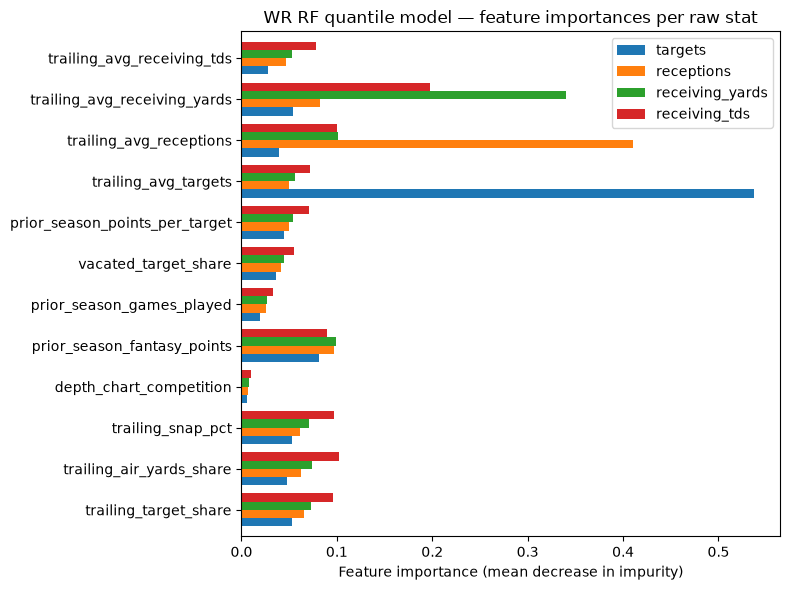

In [6]:
importances.plot.barh(figsize=(8, 6), width=0.8)
plt.xlabel("Feature importance (mean decrease in impurity)")
plt.title("WR RF quantile model — feature importances per raw stat")
plt.tight_layout()
plt.show()